In [1]:
#%matplotlib inline

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import h5py
import os
import palettable
from matplotlib.colors import LogNorm
import ipywidgets as widgets
from ipywidgets import interact, interact_manual
from scipy.ndimage.filters import uniform_filter1d
from scipy.optimize import curve_fit
import pickle
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# import tabulate
from uncertainties import ufloat
import palettable

from IPython.display import HTML, display

/var/folders/0n/31w3gh8s6kxblydlb345fy440000gn/T/ipykernel_79085/4168126211.py:12: DeprecationWarning: Please import `uniform_filter1d` from the `scipy.ndimage` namespace; the `scipy.ndimage.filters` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.ndimage.filters import uniform_filter1d


In [2]:
width_col = 3.37
width_full = 7.1014

SMALL_SIZE = 8
MEDIUM_SIZE = 10
BIGGER_SIZE = 12

matplotlib.rc('font', size=SMALL_SIZE)          # controls default text sizes
matplotlib.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
matplotlib.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
matplotlib.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
matplotlib.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
matplotlib.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
matplotlib.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
labels_transfer = {
    "UU" : r'$\mathcal{T}_\mathrm{UU}$',    
    "UUA" : r'$\mathcal{T}_\mathrm{UUa}$',
    "SS" : r'$\mathcal{T}_\mathrm{SS}$',  
    "SU" : r'$\mathcal{T}_\mathrm{SU}$',
    "US" : r'$\mathcal{T}_\mathrm{US}$',
    "UUC" : r'$\mathcal{T}_\mathrm{UUc}$',
    "BB" : r'$\mathcal{T}_\mathrm{BB}$',
    "BBA" : r'$\mathcal{T}_\mathrm{BBa}$',
    "BBC" : r'$\mathcal{T}_\mathrm{BBc}$',
    "BUT" : r'$\mathcal{T}_\mathrm{BUT}$',
    "BUP" : r'$\mathcal{T}_\mathrm{BUP}$',
    "BUPbb" : r'$\mathcal{T}_\mathrm{BUP}$',
    "UBPbb" : r'$\mathcal{T}_\mathrm{UBP}$',
    "UBPb" : r'$\mathcal{T}_\mathrm{UBP}$',
    "UBPbA" : r'$\mathcal{T}_\mathrm{UBPa}$',
    "UBPbC" : r'$\mathcal{T}_\mathrm{UBPc}$',
    "UBTb" : r'$\mathcal{T}_\mathrm{UBT}$',
    "UBTbA" : r'$\mathcal{T}_\mathrm{UBTa}$',
    "UBTbC" : r'$\mathcal{T}_\mathrm{UBTc}$',
    "FU" : r'$\mathcal{T}_\mathrm{FU}$',
    "PU" : r'$\mathcal{T}_\mathrm{PU}$',
    "nuU" : r'$\mathcal{T}_\mathrm{\nu U}$',
    "nuDivU" : r'$\mathcal{T}_\mathrm{\nu \nabla \cdot U}$',
    "etaB" : r'$\mathcal{T}_\mathrm{\eta B}$',
    "nuUreal" : r'$\mathcal{T}_\mathrm{\nu U}$',
    "nuDivUreal" : r'$\mathcal{T}_\mathrm{\nu \nabla \cdot U}$',
    "etaBreal" : r'$\mathcal{T}_\mathrm{\eta B}$',
}

labels_cross = {
    'UU' : r'$\Pi^{\mathrm{U}^<}_{\mathrm{U}^>}$',
    'BB' : r'$\Pi^{\mathrm{B}^<}_{\mathrm{B}^>}$',
    'UBTb' : r'$\Pi^{\mathrm{U}^<,\mathrm{T}}_{\mathrm{B}^>}$',
    'BUT' : r'$\Pi^{\mathrm{B}^<,\mathrm{T}}_{\mathrm{U}^>}$',
    'UBPbb' : r'$\Pi^{\mathrm{U}^<,\mathrm{P}}_{\mathrm{B}^>}$',
    'BUPbb' : r'$\Pi^{\mathrm{B}^<,\mathrm{P}}_{\mathrm{U}^>}$',
}

labels_total = {
    'UU' : r'$\partial_t E^\mathrm{UU}_\mathrm{kin}$',
    'BB' :r'$\partial_t E^\mathrm{BB}_\mathrm{mag} $',
    'UBTb' : r'$\partial_t E^\mathrm{UBT}_\mathrm{mag} $',
    'BUT' : r'$\partial_t E^\mathrm{BUT}_\mathrm{kin} $',
    'UBPbb' : r'$\partial_t E^\mathrm{UBP}_\mathrm{mag}$',
    'BUPbb' : r'$\partial_t E^\mathrm{BUP}_\mathrm{kin} $',
    'PU' : r'$\partial_t E^\mathrm{PU}_\mathrm{kin}$',
    'FU' : r'$\partial_t E^\mathrm{FU}_\mathrm{kin}$',
}

In [5]:
from entrans.config import flow_stats, sim_dict, root_dir
from entrans.data import read_data

In [6]:
all_ids  = [
    
    'data/spartha-weno3',
    'data/spartha-weno5',
    'data/spartha-weno7',
    'data/athenapk-weno3',
    'data/athenapk-weno5',
    'data/spartha-weno9',

]

In [7]:
for this_id in all_ids:
    read_data(flow_stats, this_id)

Got 3 flow stats and 3 entrans for data/spartha-weno3 at res 256
Got 3 flow stats and 3 entrans for data/spartha-weno5 at res 256
Got 3 flow stats and 3 entrans for data/spartha-weno7 at res 256
Got 3 flow stats and 3 entrans for data/athenapk-weno3 at res 256
Got 3 flow stats and 3 entrans for data/athenapk-weno5 at res 256
Got 3 flow stats and 3 entrans for data/spartha-weno9 at res 256


In [8]:
from entrans.scales import set_times, set_last_two_dumps_as_stationary, get_mean

In [9]:
for this_id in all_ids:
    print(this_id)
    set_last_two_dumps_as_stationary(this_id)
    set_times(this_id,stationary=True)   

data/spartha-weno3
data/spartha-weno3 already got stationary_ids
data/spartha-weno3
Ms = 0.216 L = 0.392 -> T = 1.812 -> time between dumps = 0.276

data/spartha-weno5
data/spartha-weno5 already got stationary_ids
data/spartha-weno5
Ms = 0.205 L = 0.375 -> T = 1.831 -> time between dumps = 0.273

data/spartha-weno7
data/spartha-weno7 already got stationary_ids
data/spartha-weno7
Ms = 0.222 L = 0.379 -> T = 1.710 -> time between dumps = 0.292

data/athenapk-weno3
data/athenapk-weno3 already got stationary_ids
data/athenapk-weno3
Ms = 0.188 L = 0.380 -> T = 2.019 -> time between dumps = 0.248

data/athenapk-weno5
data/athenapk-weno5 already got stationary_ids
data/athenapk-weno5
Ms = 0.198 L = 0.380 -> T = 1.919 -> time between dumps = 0.261

data/spartha-weno9
data/spartha-weno9 already got stationary_ids
data/spartha-weno9
Ms = 0.224 L = 0.360 -> T = 1.604 -> time between dumps = 0.312



In [10]:
line_styles = [(0, ()), 
                (0, (5, 1)),
                (0, (3, 1, 1, 1)),
                (0, (3, 2, 1, 2)),
                (0, (1, 1)),
                (0, (1, 2))]

tol_col = {
    1:  "#D6D9FF", # brighter light purple
    2:  "#BF59D1", # light purple
    3:  "#6A1AB2", # deep purple
    4:  "#1F78C1", # vivid blue
    5:  "#009E8F", # bright teal
    6:  "#3AA655", # strong green
    7:  "#F1C40F", # vibrant yellow
    8:  "#E67E22", # bold orange
    9:  "#C0392B", # vivid red
    10: "#6E2C00", # deep brown
}

sim_dict['data/spartha-weno3']['style']['color']  = tol_col[2]
sim_dict['data/spartha-weno5']['style']['color']  = tol_col[3]
sim_dict['data/spartha-weno7']['style']['color']  = tol_col[4]
sim_dict['data/spartha-weno9']['style']['color']  = tol_col[5]
sim_dict['data/athenapk-weno3']['style']['color'] = tol_col[7]
sim_dict['data/athenapk-weno5']['style']['color'] = tol_col[8]

sim_dict['data/spartha-weno3']['style']['ls']  = line_styles[0]
sim_dict['data/spartha-weno5']['style']['ls']  = line_styles[0]
sim_dict['data/spartha-weno7']['style']['ls']  = line_styles[0]
sim_dict['data/spartha-weno9']['style']['ls']  = line_styles[0]
sim_dict['data/athenapk-weno3']['style']['ls'] = line_styles[0]
sim_dict['data/athenapk-weno5']['style']['ls'] = line_styles[0]

In [11]:
######################################################################################################################
# ~~~ CA Edits ~~~
######################################################################################################################

binstr_sort_fun = lambda key : float(key.split('-')[0])

def bin_to_k(KBin):
    Low, Up = KBin.split("-")
    
    return (float(Up) + float(Low))/2.

terms_to_process = ['UU','BB','BUT','UBTb','BUPbb', 'UBPbb','PU', 'FU', 'nuU', 'etaB']

num_terms = len(terms_to_process)

for this_id in all_ids:

    # Sanity check: bins for some dump and some term
    # Will later be checked for all other terms and dumps of this sim
    some_dump = list(flow_stats[this_id]['en_trans'].keys())[0]                                 # 0
    some_term = list(flow_stats[this_id]['en_trans'][some_dump]['WW'].keys())[0]                # UUA
    some_entrans_term = flow_stats[this_id]['en_trans'][some_dump]['WW'][some_term]['AnyToAny'] # From Q to K vals for UUA
    bins_this_sim = sorted(some_entrans_term.keys(), key=binstr_sort_fun)                       # Ordered Bins ['0.00-3.36', '3.36-4.00', ..., '90.51-107.63', '107.63-128.00']    
    num_bins = len(bins_this_sim)                                                               # 22

    entrans_type = np.dtype(                             # Structured data type (e.g., data = np.zeros(3, dtype=entrans_type))
        [('term', 'U10'),                                # A field named "term"           storing a unicode string up to 10 characters long
         ('shell-to-shell', 'f8', (num_bins, num_bins)), # A field named "shell-to-shell" storing a 2D float array (float64, since 'f8' = 8-byte float) with shape (num_bins, num_bins)
         ('total', 'f8', (num_bins)),                    # A field named "total"          storing a 1D float array of length num_bins
         ('cross', 'f8', (num_bins - 1)),                # A field named "cross"          storing a 1D float array of length num_bins - 1
        ])    
    
    k_center = list(map(lambda this_bin : bin_to_k(this_bin), bins_this_sim)) # centers of bins (22 vals)
    
    flow_stats[this_id]['en_trans_x'] = {                                                                  # Creates a new dictionary assigned to flow_stats[this_id]['en_trans_x'] with four keys: 'bins', 'shell-to-shell', 'total', and 'cross'
        'bins' : bins_this_sim,                                                                            # ['0.00-3.36', '3.36-4.00', ..., '90.51-107.63', '107.63-128.00'] 
        'shell-to-shell' : np.array(list(map(lambda this_bin : bin_to_k(this_bin), bins_this_sim))),       # [    1.68         3.68     ...      99.07           117.815    ] splits bins_this_sim and takes the average of the first and second element 
        'total' : np.array(list(map(lambda this_bin : bin_to_k(this_bin), bins_this_sim))),                # [    1.68         3.68     ...      99.07           117.815    ] splits bins_this_sim and takes the average of the first and second element 
        'cross' : np.array(list(map(lambda this_bin : float(this_bin.split('-')[1]), bins_this_sim))[:-1]) # [      3.36         4.00   ...         107.63                  ] splits bins_this_sim and takes the second element (excluding the final bin)
    }
    
    
    for this_dump in flow_stats[this_id]['en_trans'].keys(): # e.g., 0 to 101 for Got 101 flow stats and 101 entrans for oct-9th/spa-turb-256-Ms-0.2-WENO3 at res 256

        # Skips all data outside stationary_ids
        if (this_dump < sim_dict[this_id]['stationary_ids'][0] or
            this_dump > sim_dict[this_id]['stationary_ids'][1]):
            continue

        this_dump_data = flow_stats[this_id]['en_trans'][this_dump] # All en_trans data for this_dump

        terms_present = [] 
        for this_term in terms_to_process:
            if this_term not in list(this_dump_data['WW'].keys()):
                print("skipping (missing) ", this_id, this_dump, this_term)
                continue
            #if 'eta' in this_term and 'eta' not in this_id:
            #    print("skipping (ILES) ", this_id, this_dump, this_term)
            #    continue
            #if 'nu' in this_term and 'nu' not in this_id:
            #    print("skipping (ILES) ", this_id, this_dump, this_term)
            #    continue
            terms_present.append(this_term)
            
        this_dump_data['processed'] = np.zeros(len(terms_present), dtype=entrans_type)

        for t, this_term in enumerate(terms_present):

            ##############################################################
            # 1.0 convert double dict into single numpy array
            this_term_data = this_dump_data['WW'][this_term]['AnyToAny'] # {'0.00-3.36': {'0.00-3.36': 57.45093582146637, '3.36-4.00': -59183.11322837485, ...
            k_bins = sorted(this_term_data.keys(), key=binstr_sort_fun)  # ['0.00-3.36', '3.36-4.00', '4.00-4.76', ...
            assert k_bins == bins_this_sim, f"Mismatch in k_bins term {this_term} dump {this_dump} kbins {k_bins} expected {bins_this_sim}"

            ##############################################################
            # 1.5 initialize data with nan to later sanity check & fill in this_term_data
            this_term_data_processed = np.empty((num_bins,num_bins), dtype=np.float64) * np.nan # 22x22 of nans
            for i, k_bin in enumerate(k_bins):
                q_bins = sorted(this_term_data[k_bin].keys(), key=binstr_sort_fun) # ['0.00-3.36', '3.36-4.00', '4.00-4.76', ... 
                try:
                    assert q_bins == bins_this_sim, "Mismatch in q_bins: %s %s" % (this_id, this_term)
                except AssertionError:
                    print(f"Failing at {q_bins} for term {this_term} at snap {this_dump}.\n Expected {bins_this_sim}")
                    raise AssertionError
                for j, q_bin in enumerate(q_bins):
                    this_term_data_processed[i,j] = this_term_data[k_bin][q_bin] # 57.45093582146637, -59183.11322837485, ...
            
            # check sanity for nans present 
            assert not np.isnan(this_term_data_processed).any(), "processed array not fully filled" + this_id +  str(this_dump) +  this_term

            ##############################################################
            # 2.0 calculate cross scale fluxes    
            # initialialize with nan for sanity check later
            # \Pi_{Y>}^{X<} (k) = \sum_{Q \leq k} \sum_{K > k} \mathcal{T}_{XY} (Q, K)
            cross_data = np.empty((num_bins-1), dtype=np.float64) * np.nan
            for i in range(1,num_bins):
                cross_data[i-1] = np.sum(this_term_data_processed[i:,:i])
            assert not np.isnan(cross_data).any(), "cross array not filled"

            ##############################################################
            # 3.0 calculate total fluxes    

            # total_data = E^{\cdot}_{XY}(K) = \sum_{Q} \mathcal{T}_{XY}(Q,K)
            total_data = np.sum(this_term_data_processed, axis=1)
            this_dump_data['processed']['term'][t] = this_term                          # storing a unicode string up to 10 characters long
            this_dump_data['processed']['shell-to-shell'][t] = this_term_data_processed # storing a 2D float array with shape (num_bins, num_bins)
            this_dump_data['processed']['total'][t] = total_data                        # storing a 1D float array of length num_bins
            this_dump_data['processed']['cross'][t] = cross_data                        # storing a 1D float array of length num_bins - 1


In [12]:
from scipy import optimize
from scipy.optimize import minimize

terms_kin = ['UU', 'BUT', 'BUPbb', 'PU', 'FU']
terms_mag = ['BB', 'UBTb', 'UBPbb']

terms_iles =  terms_kin + terms_mag

terms_diss = ['nuU', 'etaB', 'nuDivU','nu2U', 'eta2B']

all_terms = terms_kin + terms_mag + terms_diss


In [13]:
######################################################################################################################
# ~~~ CA Edits ~~~
######################################################################################################################

def add_flux_to_plot(p, this_id, flux, terms):
    
    assert flux == 'cross' or flux == 'total', "Unknown flux"
    assert len(terms) > 0, "List of terms should contain entries"
    
    # midpoint of the bins
    # array([  1.68 ,   3.68 ,   4.38 ,   5.21 ,   6.195,   7.365,   8.755,
    #         10.41 ,  12.38 ,  14.725,  17.515,  20.83 ,  24.77 ,  29.455,
    #         35.025,  41.65 ,  49.535,  58.91 ,  70.055,  83.31 ,  99.07 , 117.815])
    k = np.copy(flow_stats[this_id]['en_trans_x'][flux])
    x = k 

    all_data = []                        # user defined terms
    mean_total_net_flux_no_diss = []     # ['UU', 'BB', 'BUT', 'UBTb', 'BUPbb', 'UBPbb', 'PU']
    mean_total_net_flux_no_diss_kin = [] # ['UU', 'BUT', 'BUPbb', 'PU', 'FU']
    mean_total_net_flux_no_diss_mag = [] # ['BB', 'UBTb', 'UBPbb']
    ca_flux = []

    ### carefull assuming nu=eta here
    #diss_coeff = float(this_id.split('-')[-1])
    # proxy for dissipation

    # E^{\cdot}_{XY}(K) = \sum_{Q} \mathcal{T}_{XY}(Q,K)
    Edot = []
    
    etaB_data = []
    
    for this_dump in flow_stats[this_id]['en_trans'].keys():

        
        # Skips all data outside stationary_ids
        if (this_dump < sim_dict[this_id]['stationary_ids'][0] or
            this_dump > sim_dict[this_id]['stationary_ids'][1]):
            continue

        # All processed en_trans data for this_dump (dtype=entrans_type)
        # [('UU',   [[ 5.62070014e+01, -7.80430011e+04, ...  ( 'UU' , [[22], [22] ... [22]], [  22   ], [  21   ] ) 
        # ('BB',    [[ 4.14451803e-01, -2.87417121e+03, ...  ('term', [  'shell-to-shell' ], ['total'], ['cross'] )
        # ('BUT',   [[-1.77819948e+04, -3.63705988e+03, ...  
        # ('UBTb',  [[ 1.77819948e+04,  1.32482089e+03, ...    
        # ('BUPbb', [[-1.40569594e+02, -1.10467090e+01, ...  
        # ('UBPbb', [[ 1.40569594e+02, -6.55502249e+00, ...  
        # ('PU',    [[ 3.11661921e+03,  1.44352899e+02, ...   
        # ('FU',    [[ 3.01409703e+05,  1.35284729e-08, ...   
        # ('nuU',   [[-1.62868407e+08,  7.20518946e+04, ...   
        # ('etaB',  [[-5.98695325e+06, -2.18278728e-11, ...  
        # ('nuDivU',[[-6.31487974e+04, -1.09139364e-11, ... ] 
        data = flow_stats[this_id]['en_trans'][this_dump]['processed']

        # NO IDEA WHY THIS IS HERE
        Edot.append(np.sum(data[data['term'] == 'FU']['total']))
        
        ##############################################################
        # Sum of Kinetic Terms ['UU', 'BUT', 'BUPbb', 'PU', 'FU']
        mask = False
        for term in terms_kin:

            # terms_kin                         = ['UU',         'BUT',       'BUPbb',        'PU', 'FU'                        ]
            # data['term']                      = ['UU'   'BB'   'BUT' 'UBTb' 'BUPbb' 'UBPbb' 'PU'  'FU'  'nuU'  'etaB' 'nuDivU']
            # mask (at the end of the for loop) = [ True  False  True  False  True    False   True  True  False  False  False   ] 
            mask = np.logical_or(mask, data['term'] == term)
            
        # an array of length num_bins that sums the 'total' transfer of the terms_kin (data[mask]['total'] is 5x22, and np.sum(data[mask]['total'], axis=0) is 1x22)
        mean_total_net_flux_no_diss_kin.append(np.sum(data[mask]['total'], axis=0))        
        
        ##############################################################
        # Sum of Magnetic Terms ['BB', 'UBTb', 'UBPbb']
        mask = False
        for term in terms_mag:
            mask = np.logical_or(mask, data['term'] == term)
    
        # an array of length num_bins that sums the 'total' transfer of the terms_mag (data[mask]['total'] is 3x22, and np.sum(data[mask]['total'], axis=0) is 1x22)
        mean_total_net_flux_no_diss_mag.append(np.sum(data[mask]['total'], axis=0))          

        ##############################################################
        # Sum of Non-Dissipative Terms (excluding ['nuU'  'etaB' 'nuDivU'])
        mask = False
        for term in ['UU', 'BB', 'BUT', 'UBTb', 'BUPbb', 'UBPbb', 'PU']:
            mask = np.logical_or(mask, data['term'] == term)
        
        mean_total_net_flux_no_diss.append(np.sum(data[mask]['total'], axis=0))

        if 'eta' in this_id:
            for term in ['nuUreal', 'etaBreal', 'nuDivUreal']:
                mask = np.logical_or(mask, data['term'] == term)            
        
        ##############################################################
        # always normalize to the max total (i.e., all processed terms) cross scale flux
        # np.sum takes data[mask]['cross'] from 7x21 for the non-diss terms to shape 21
        total_cross_flux = np.sum(data[mask]['cross'], axis=0)
        total_net_flux   = np.sum(data[mask]['total'], axis=0)

        ##############################################################
        # Mask of user defined terms
        mask = False
        for term in terms:
            # print("using: ", term)
            mask = np.logical_or(mask, data['term'] == term)

        # masks data for only user defined terms
        data = data[mask]
       

        orig_flux = data[flux] # shape 3x22
        total_flux = np.sum(data[flux], axis=0) # shape 1x22
        # print(orig_flux == total_flux, orig_flux.shape, total_flux.shape)
        all_data.append(total_flux/np.max(total_cross_flux)) # normalized 
        # all_data.append(total_flux/np.max(total_net_flux  )) # normalized 

        
        
    all_data = np.array(all_data)
    # mean_total_net_flux_no_diss starts as # of stationary x 22 then computes the mean for each k so its 1x22
    mean_total_net_flux_diss        = np.mean(all_data,                       axis=0)
    mean_total_net_flux_no_diss     = np.mean(mean_total_net_flux_no_diss,    axis=0)
    mean_total_net_flux_no_diss_kin = np.mean(mean_total_net_flux_no_diss_kin,axis=0)
    mean_total_net_flux_no_diss_mag = np.mean(mean_total_net_flux_no_diss_mag,axis=0)


    mean_total_net_flux_no_diss = mean_total_net_flux_no_diss
    mean_total_net_flux_no_diss_kin = mean_total_net_flux_no_diss_kin
    mean_total_net_flux_no_diss_mag = mean_total_net_flux_no_diss_mag


    # print(np.std(Edot)/np.mean(Edot))
    Edot = np.mean(Edot)
    # kolmogorov microscale
    #eta_k = (diss_coeff ** 3 / Edot) **(1./4.)
    #print(this_id, eta_k)
    #x *= eta_k * (sim_dict[this_id]['analysis_res']/2)
    
    #etaB_mean = np.mean(etaB_data,axis=0)
    #idxmax = np.argmax(etaB_mean)
    #print(idxmin)
    #x /= x[idxmax]
    #p.plot(x, etaB_mean)
    
    #x /= sim_dict[this_id]['forcing_scale']
    k_total = np.copy(flow_stats[this_id]['en_trans_x']['total'])

    mask = k_total > 8 * sim_dict[this_id]['forcing_scale']


    #xmax = k_total[mask][np.argmax(total_net_flux_no_diss[mask])]
    xmax = k_total[mask][np.argmax(mean_total_net_flux_no_diss[mask])]
    sim_dict[this_id]['peak_num_diss'] = xmax

    sim_dict[this_id]['peak_num_diss_kin'] = k_total[mask][np.argmax(mean_total_net_flux_no_diss_kin[mask])]
    sim_dict[this_id]['peak_num_diss_mag'] = k_total[mask][np.argmax(mean_total_net_flux_no_diss_mag[mask])]
    

    label_of_terms = " + ".join(terms)
    
    k_diss = k_total[mask][np.argmax(mean_total_net_flux_no_diss[mask])] 
    E_diss = np.interp(k_diss, k_total[mask], mean_total_net_flux_no_diss[mask])


    # print(sim_dict[this_id]['style']['label'], 'peak_num_diss: ',sim_dict[this_id]['peak_num_diss'],   'peak_num_diss_kin: ', k_total[mask][np.argmax(mean_total_net_flux_no_diss_kin[mask])], 'peak_num_diss_mag: ', k_total[mask][np.argmax(mean_total_net_flux_no_diss_mag[mask])]  )

    # x /= xmax

    y = np.mean(all_data,axis=0)
    y_err = [
        np.mean(all_data,axis=0)-np.std(all_data,axis=0),
        np.mean(all_data,axis=0)+np.std(all_data,axis=0)
    ]
    if p is not None:        
        p.plot(x, y, lw=1.0, **sim_dict[this_id]['style'])
        p.fill_between(x,
                          y_err[0],
                          y_err[1],
                         alpha=0.3, color=sim_dict[this_id]['style']['color'])
    return x, y, y_err



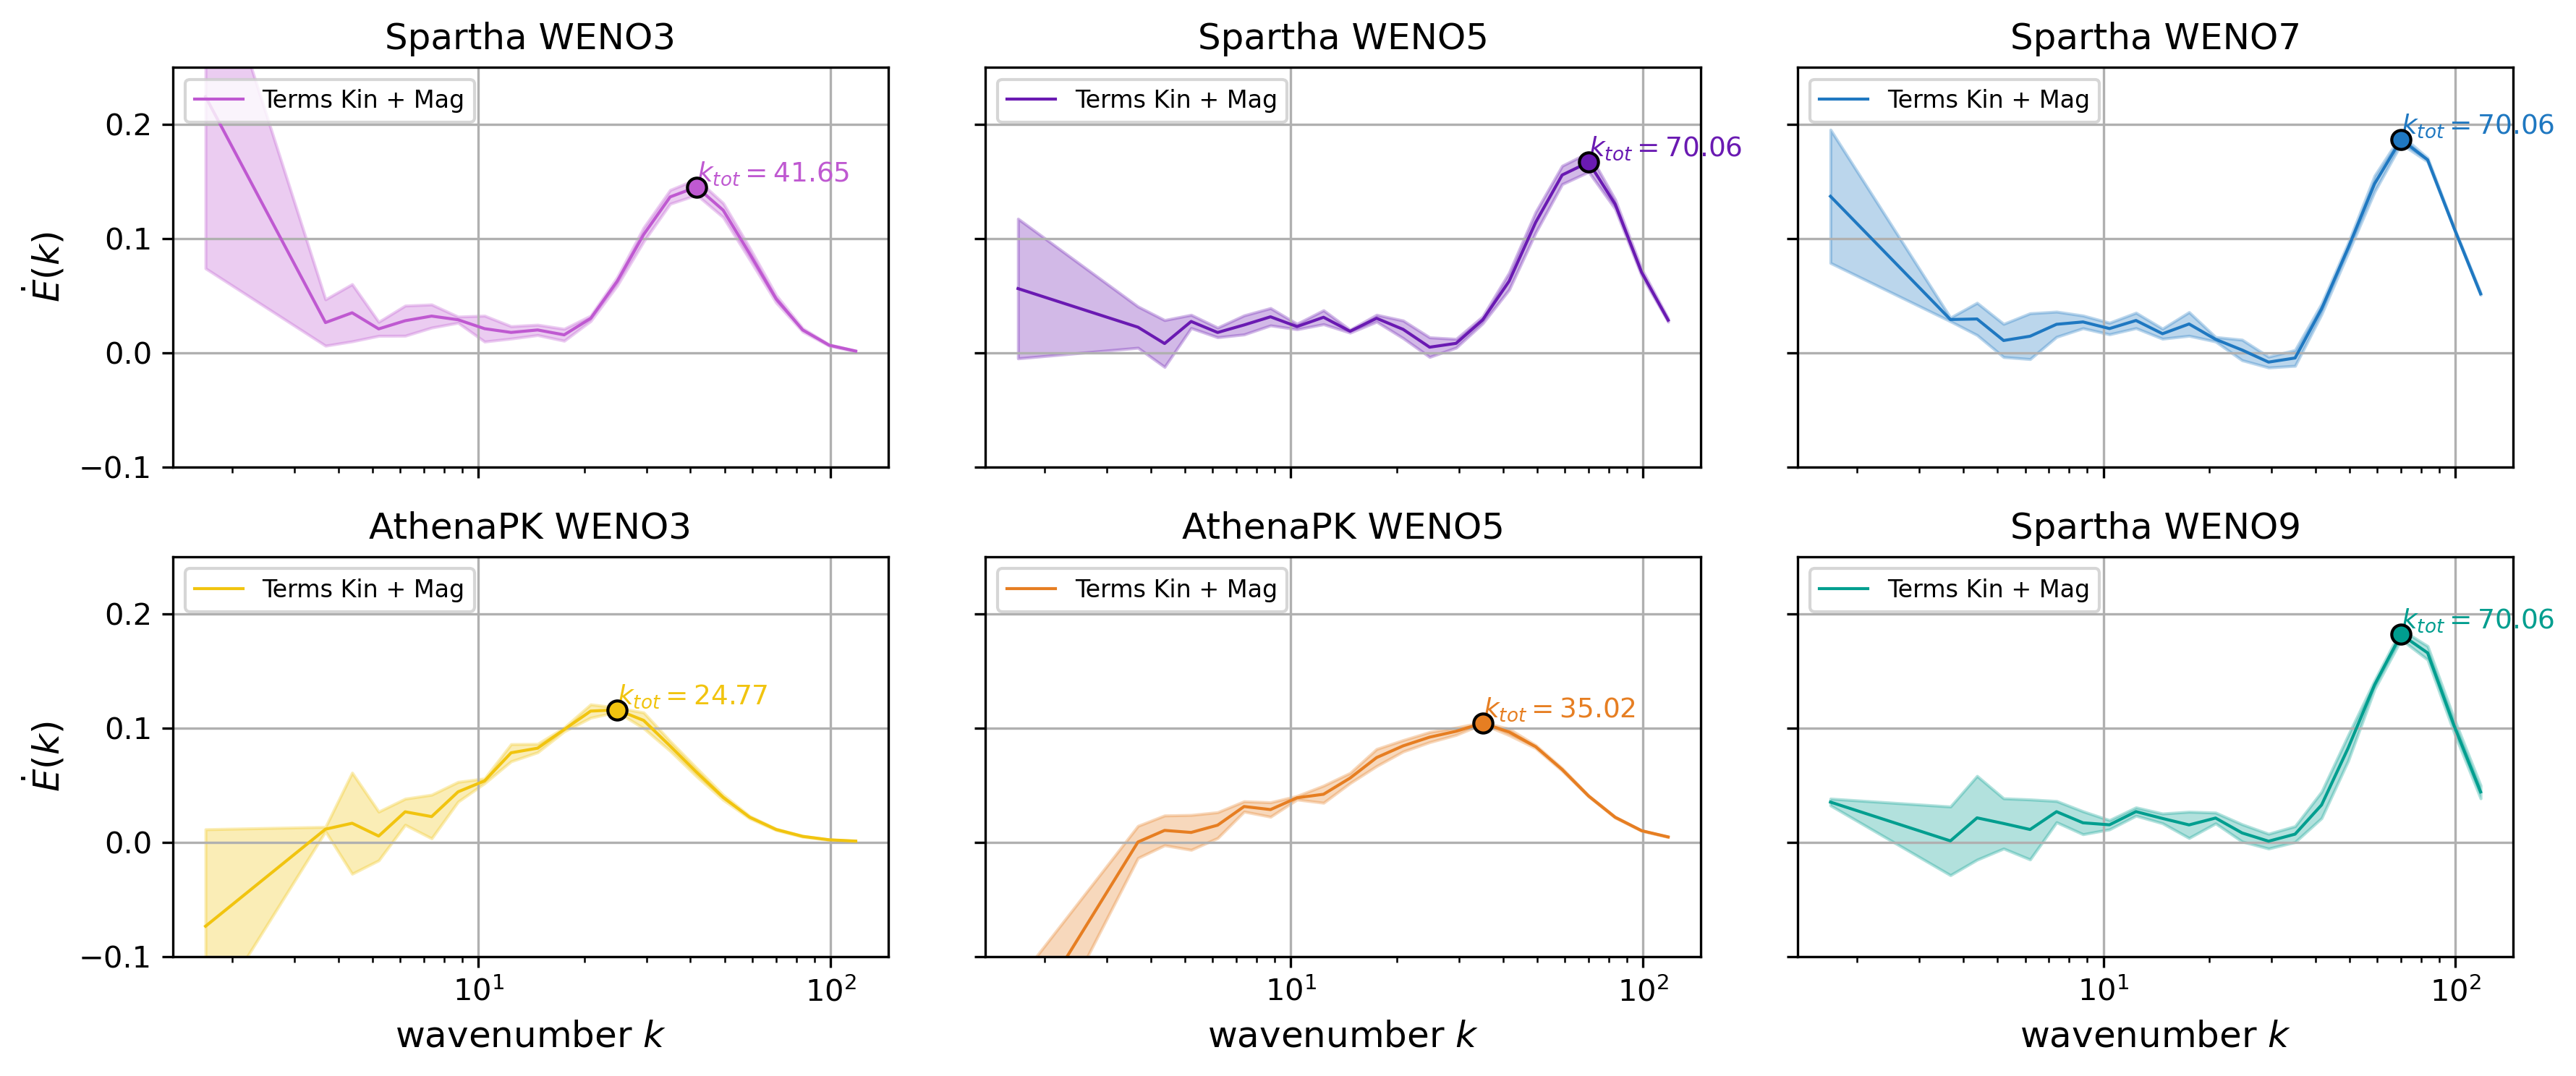

In [14]:
ids_this_plot = all_ids

term = 'tot'
# term = 'kin'
# term = 'mag'

fig, p = plt.subplots(2, 3, sharex=True, sharey=True, figsize=(12, 5),dpi=300)

p = p.flatten()  # make it easier to index 0–5 instead of [row][col]

terms_kin = ['UU', 'BUT', 'BUPbb', 'PU', 'FU']
terms_mag = ['BB', 'UBTb', 'UBPbb']
terms_iles =  terms_kin + terms_mag

for i, this_id in enumerate(ids_this_plot):
    
    
    ##########################################################################
    if term == 'tot':
        terms_data_all = terms_iles.copy()
    elif term == 'kin':
        terms_data_all = terms_kin.copy()
    elif term == 'mag':
        terms_data_all = terms_mag.copy()
    ##########################################################################

    if 'eta' in this_id:
        # terms_data_all += terms_diss_real
        print('eta is present for ', this_id)
    
    k_center, data_all, err_all = add_flux_to_plot(None, this_id, 'total', terms_data_all)

    ##########################################################################
    if term == 'tot':
        p[i].plot(k_center, data_all, label="Terms Kin + Mag", lw=1.0,color=sim_dict[this_id]['style']['color'])
    elif term == 'kin':
        p[i].plot(k_center, data_all, label="Terms Kin", lw=1.0,color=sim_dict[this_id]['style']['color'])
    elif term == 'mag':
        p[i].plot(k_center, data_all, label="Terms Mag", lw=1.0,color=sim_dict[this_id]['style']['color'])
    ##########################################################################

    p[i].fill_between(k_center, err_all[0], err_all[1], alpha=0.3,color=sim_dict[this_id]['style']['color'])

    k_center, data_iles, err_iles = add_flux_to_plot(None, this_id, 'total', terms_iles)    
    
    p[i].set_xscale("log")
    p[i].grid()
    p[i].set_title(sim_dict[this_id]['style']['label'], fontsize=12)

    p[i].legend(fontsize=8, bbox_to_anchor=(0, 1), loc="upper left")

    ##########################################################################
    if term == 'tot':
        k_peak = sim_dict[this_id]['peak_num_diss']
    elif term == 'kin':
        k_peak = sim_dict[this_id]['peak_num_diss_kin']
    elif term == 'mag':
        k_peak = sim_dict[this_id]['peak_num_diss_mag']
    ##########################################################################

    y_peak = np.interp(k_peak, k_center, data_all)

    p[i].scatter(k_peak,y_peak,color=sim_dict[this_id]['style']['color'],edgecolor='black',s=40,zorder=5,)


    ##########################################################################
    if term == 'tot':
        p[i].text(k_peak,y_peak,rf"$k_{{tot}} = {k_peak:.2f}$",fontsize=9,color=sim_dict[this_id]['style']['color'],ha='left',va='bottom')
    elif term == 'kin':
        p[i].text(k_peak,y_peak,rf"$k_{{\nu}} = {k_peak:.2f}$",fontsize=9,color=sim_dict[this_id]['style']['color'],ha='left',va='bottom')
    elif term == 'mag':
        p[i].text(k_peak,y_peak,rf"$k_{{\eta}} = {k_peak:.2f}$",fontsize=9,color=sim_dict[this_id]['style']['color'],ha='left',va='bottom')
    ##########################################################################


##############################################################################
if term == 'tot':
    p[1].set_ylim([-0.1,0.25]) # all
elif term == 'kin':
    p[1].set_ylim([-0.15, 0.55]) # kin
elif term == 'mag':
    p[1].set_ylim([-0.45,0.15]) # mag
##############################################################################

# add shared x-label to bottom row
for ax in p[3:]:
    # ax.set_xlabel(r'wavenumber $k/k_\mathrm{d}$',fontsize=12)
    ax.set_xlabel(r'wavenumber $k$',fontsize=12)

for ax in p:

    ax.tick_params(axis='both', labelsize=10)


p[0].set_ylabel(r"$\dot E(k)$",fontsize=12)
p[3].set_ylabel(r"$\dot E(k)$",fontsize=12)

fig.tight_layout()


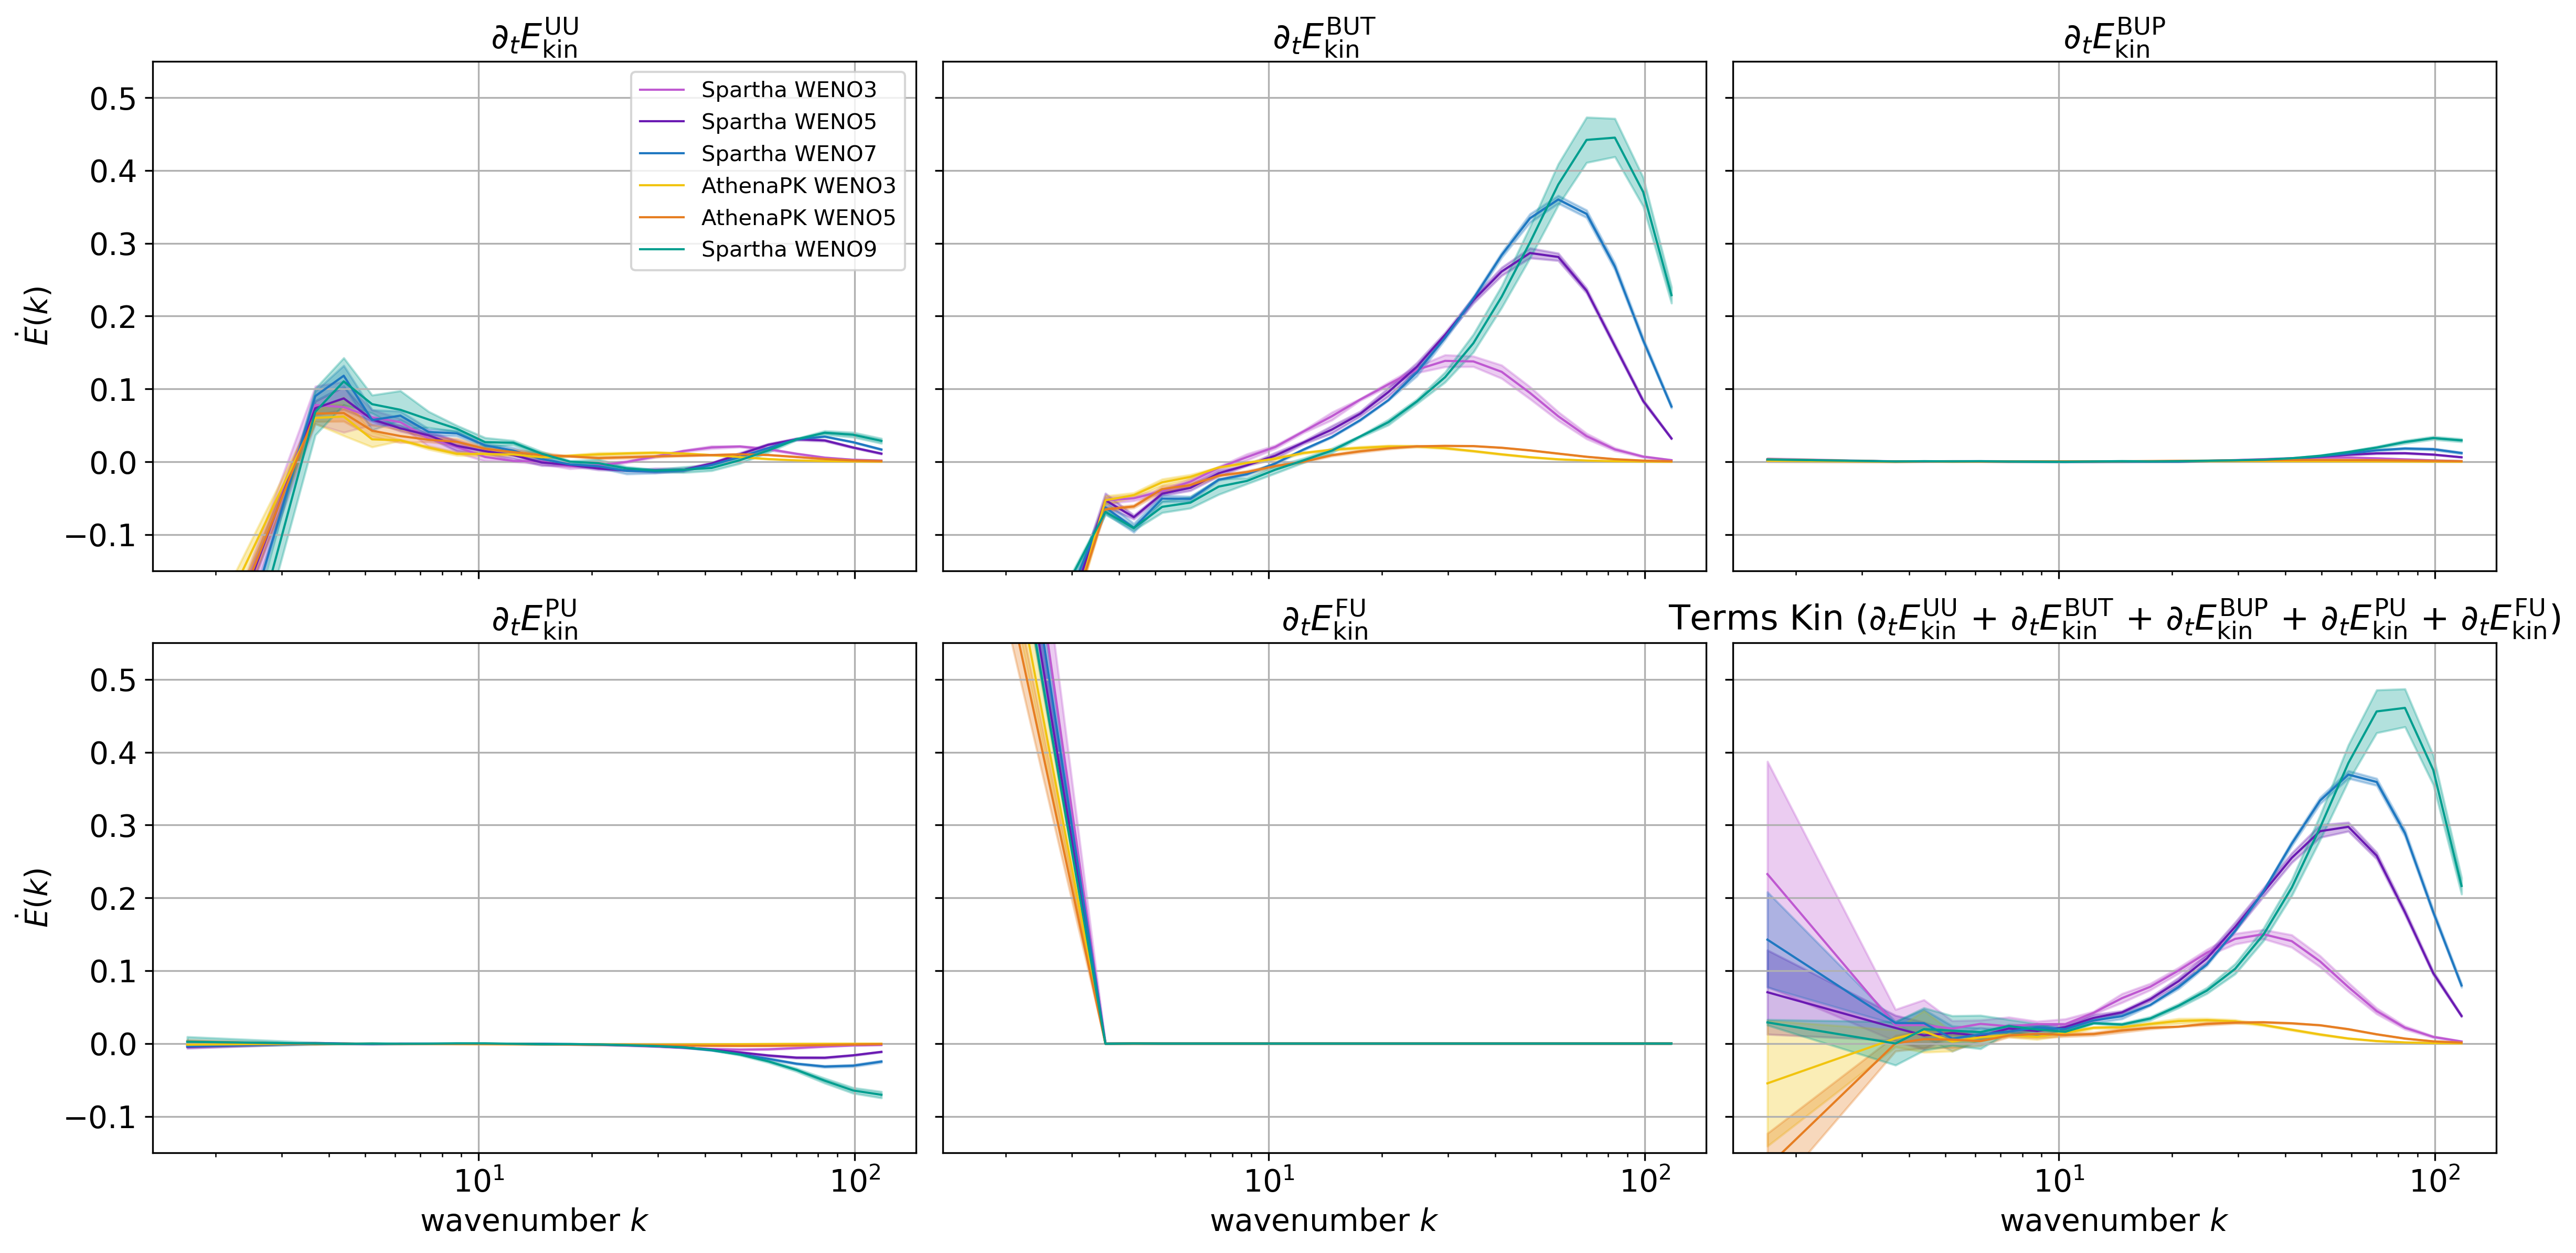

In [15]:
ids_this_plot = all_ids

terms_kin = ['UU', 'BUT', 'BUPbb', 'PU', 'FU']

fig, plots = plt.subplots(
    2, 3,
    figsize=(16, 8),
    sharex=True,
    sharey=True,
    dpi=300
)

##########################################################################
# (0,0)
##########################################################################
ax = plots[0, 0]
term = 'UU'

for this_id in ids_this_plot:
    k, y, err = add_flux_to_plot(None, this_id, 'total', [term])
    ax.plot(k, y, lw=1.0, color=sim_dict[this_id]['style']['color'],
            label=sim_dict[this_id]['style']['label'])
    ax.fill_between(k, err[0], err[1], alpha=0.3,
                    color=sim_dict[this_id]['style']['color'])

ax.set_title(labels_total[term], fontsize=16)
ax.set_xscale("log")
ax.grid()
ax.legend(fontsize=10)

##########################################################################
# (0,1)
##########################################################################
ax = plots[0, 1]
term = 'BUT'

for this_id in ids_this_plot:
    k, y, err = add_flux_to_plot(None, this_id, 'total', [term])
    ax.plot(k, y, lw=1.0, color=sim_dict[this_id]['style']['color'])
    ax.fill_between(k, err[0], err[1], alpha=0.3,
                    color=sim_dict[this_id]['style']['color'])

ax.set_title(labels_total[term], fontsize=16)
ax.set_xscale("log")
ax.grid()

##########################################################################
# (0,2)
##########################################################################
ax = plots[0, 2]
term = 'BUPbb'

for this_id in ids_this_plot:
    k, y, err = add_flux_to_plot(None, this_id, 'total', [term])
    ax.plot(k, y, lw=1.0, color=sim_dict[this_id]['style']['color'])
    ax.fill_between(k, err[0], err[1], alpha=0.3,
                    color=sim_dict[this_id]['style']['color'])

ax.set_title(labels_total[term], fontsize=16)
ax.set_xscale("log")
ax.grid()

##########################################################################
# (1,0)
##########################################################################
ax = plots[1, 0]
term = 'PU'

for this_id in ids_this_plot:
    k, y, err = add_flux_to_plot(None, this_id, 'total', [term])
    ax.plot(k, y, lw=1.0, color=sim_dict[this_id]['style']['color'])
    ax.fill_between(k, err[0], err[1], alpha=0.3,
                    color=sim_dict[this_id]['style']['color'])

ax.set_title(labels_total[term], fontsize=16)
ax.set_xscale("log")
ax.grid()

##########################################################################
# (1,1)
##########################################################################
ax = plots[1, 1]
term = 'FU'

for this_id in ids_this_plot:
    k, y, err = add_flux_to_plot(None, this_id, 'total', [term])
    ax.plot(k, y, lw=1.0, color=sim_dict[this_id]['style']['color'])
    ax.fill_between(k, err[0], err[1], alpha=0.3,
                    color=sim_dict[this_id]['style']['color'])

ax.set_title(labels_total[term], fontsize=16)
ax.set_xscale("log")
ax.grid()

##########################################################################
# (1,2)
##########################################################################
ax = plots[1, 2]

for this_id in ids_this_plot:
    k, y, err = add_flux_to_plot(None, this_id, 'total', ['UU', 'BUT', 'BUPbb', 'PU', 'FU'])
    ax.plot(k, y, lw=1.0, color=sim_dict[this_id]['style']['color'])
    ax.fill_between(k, err[0], err[1], alpha=0.3,
                    color=sim_dict[this_id]['style']['color'])

label = f"Terms Kin ({labels_total['UU']} + {labels_total['BUT']} + {labels_total['BUPbb']} + {labels_total['PU']} + {labels_total['FU']})"
ax.set_title(label, fontsize=16)
ax.set_xscale("log")
ax.grid()

##########################################################################
# Shared labels
##########################################################################
plots[0, 0].set_ylabel(r"$\dot{E}(k)$", fontsize=14)
plots[1, 0].set_ylabel(r"$\dot{E}(k)$", fontsize=14)

plots[1, 0].set_xlabel(r"wavenumber $k$", fontsize=14)
plots[1, 1].set_xlabel(r"wavenumber $k$", fontsize=14)
plots[1, 2].set_xlabel(r"wavenumber $k$", fontsize=14)

for ax in plots.flat:
    ax.set_ylim(-0.15, 0.55)
    
    ax.tick_params(axis='both', labelsize=14)

fig.tight_layout()
plt.show()

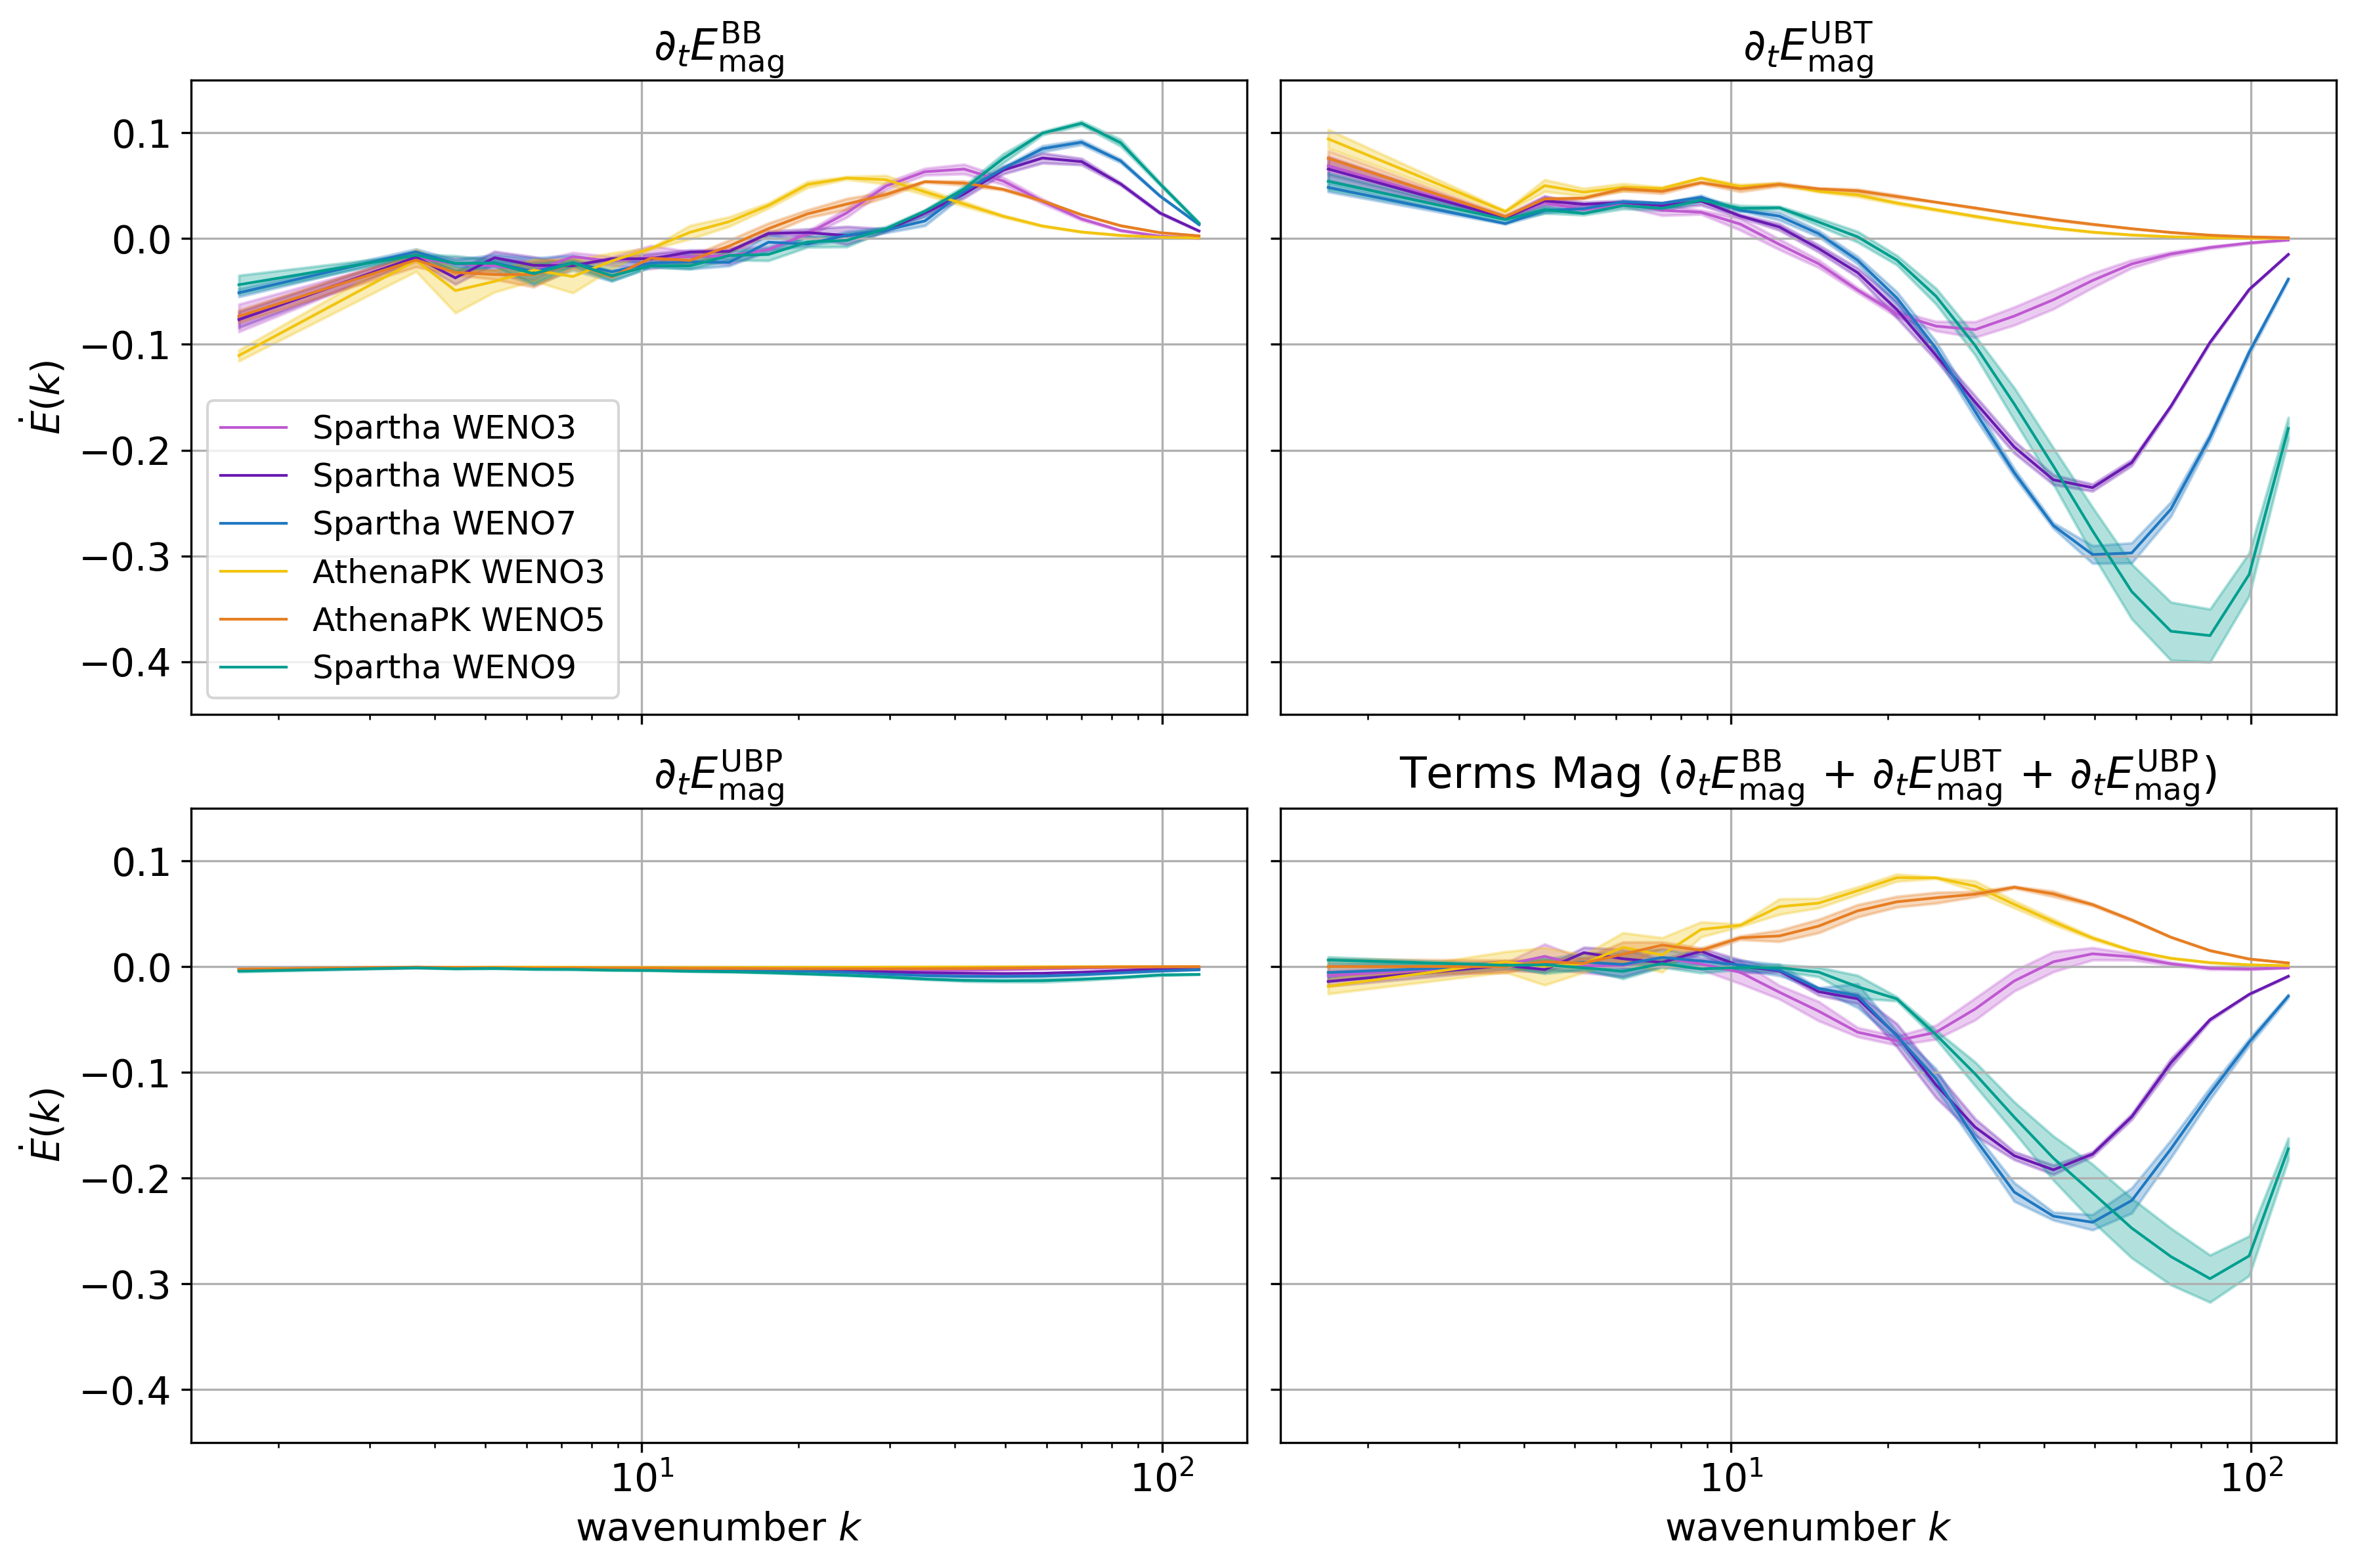

In [16]:
ids_this_plot = all_ids

fig, plots = plt.subplots(
    2, 2,
    figsize=(12, 8),
    sharex=True,
    sharey=True,
    dpi=300
)

# flatten NOT used on purpose to keep explicit indexing
# terms_mag = ['BB', 'UBTb', 'UBPbb']

##########################################################################
# Plot (0,0)
##########################################################################
ax = plots[0, 0]

for this_id in ids_this_plot:
    term = 'BB'
    k_center, data_all, err_all = add_flux_to_plot(None, this_id, 'total',[term])
    ax.plot(k_center, data_all, lw=1.0,color=sim_dict[this_id]['style']['color'],label=sim_dict[this_id]['style']['label'])
    ax.fill_between(k_center, err_all[0], err_all[1], alpha=0.3,color=sim_dict[this_id]['style']['color'])
    
ax.set_title(labels_total[term], fontsize=16)
ax.set_xscale("log")
ax.grid()
ax.legend(fontsize=12)

##########################################################################
# Plot (0,1)
##########################################################################
ax = plots[0, 1]

for this_id in ids_this_plot:
    term = 'UBTb'
    k_center, data_all, err_all = add_flux_to_plot(None, this_id, 'total', [term])
    ax.plot(k_center, data_all, lw=1.0,color=sim_dict[this_id]['style']['color'])
    ax.fill_between(k_center, err_all[0], err_all[1], alpha=0.3,color=sim_dict[this_id]['style']['color'])
    
ax.set_title(labels_total[term], fontsize=16)
ax.set_xscale("log")
ax.grid()
# ax.legend(fontsize=7)

##########################################################################
# Plot (1,0)
##########################################################################
ax = plots[1, 0]

for this_id in ids_this_plot:
    term = 'UBPbb'
    k_center, data_all, err_all = add_flux_to_plot(None, this_id, 'total', [term])
    ax.plot(k_center, data_all, lw=1.0,color=sim_dict[this_id]['style']['color'])
    ax.fill_between(k_center, err_all[0], err_all[1], alpha=0.3,color=sim_dict[this_id]['style']['color'])
    
ax.set_title(labels_total[term], fontsize=16)
ax.set_xscale("log")
ax.grid()


##########################################################################
# Plot (1,1)
##########################################################################
ax = plots[1, 1]

for this_id in ids_this_plot:
    k_center, data_all, err_all = add_flux_to_plot(None, this_id, 'total', ['BB', 'UBTb', 'UBPbb'])
    ax.plot(k_center, data_all, lw=1.0,color=sim_dict[this_id]['style']['color'])
    ax.fill_between(k_center, err_all[0], err_all[1], alpha=0.3,color=sim_dict[this_id]['style']['color'])
   
label = f"Terms Mag ({labels_total['BB']} + {labels_total['UBTb']} + {labels_total['UBPbb']})"
ax.set_title(label, fontsize=16)
ax.set_xscale("log")
ax.grid()


##########################################################################
# Shared labels
##########################################################################
plots[0, 0].set_ylabel(r"$\dot{E}(k)$", fontsize=14)
plots[1, 0].set_ylabel(r"$\dot{E}(k)$", fontsize=14)

# plots[1, 0].set_xlabel(r'wavenumber $k/k_\mathrm{d}$',fontsize=14)
# plots[1, 1].set_xlabel(r'wavenumber $k/k_\mathrm{d}$',fontsize=14)
plots[1, 0].set_xlabel(r'wavenumber $k$',fontsize=14)
plots[1, 1].set_xlabel(r'wavenumber $k$',fontsize=14)

for ax in plots.flat:
    ax.set_ylim(-0.45,0.15)
    ax.tick_params(axis='both', labelsize=14)

fig.tight_layout()
plt.show()

In [17]:
def get_mean_spec(this_id,ana_res,quan,tlim_low=8.0,tlim_up=10.0):
    tmp = []    
    for Dump in flow_stats[this_id][ana_res].keys():
        if (Dump * sim_dict[this_id]['time_between_dumps'] < tlim_low or
            Dump * sim_dict[this_id]['time_between_dumps'] > tlim_up):
            continue
        # normalize to 1
        norm = np.trapezoid(flow_stats[this_id][ana_res][Dump][quan][1],
                           x=flow_stats[this_id][ana_res][Dump][quan][0])        
        tmp.append(flow_stats[this_id][ana_res][Dump][quan][1]/norm
                   )
                   #np.sum(flow_stats[this_id][ana_res][Dump][quan][1]))
    print(this_id, "Used %d spec" % len(tmp))
    return flow_stats[this_id][ana_res][Dump][quan][0],  np.mean(tmp,axis=0), np.std(tmp,axis=0)

def add_mean_spec_to_plot(this_id, ana_res, quan, tlim_low=8.0, tlim_up=10.0, use_norm = None):

    
    X,Y, Yerr = get_mean_spec(this_id,ana_res,quan,tlim_low=tlim_low,tlim_up=tlim_up)
    
    mask = np.logical_and(X < ana_res/2,X != 0.)
    
    if use_norm is None:        
        norm = 1.0
        ennorm = 1.0
    elif use_norm == "k_f":
        norm = sim_dict[this_id]['forcing_scale']

        mask_ennorm = np.logical_and(X/norm >= 1.5,X/norm <= 6.0)

        #p.axvline(X[mask_ennorm][0]/norm)
        #p.axvline(X[mask_ennorm][-1]/norm)
        ennorm = np.trapezoid(Y[mask_ennorm], x=X[mask_ennorm]/norm)

        X, Y_U, Yerr_U = get_mean_spec(this_id,ana_res,"rhoU/PowSpec/Full",tlim_low=tlim_low,tlim_up=tlim_up)
        X, Y_B, Yerr_B = get_mean_spec(this_id,ana_res,"B/PowSpec/Full",tlim_low=tlim_low,tlim_up=tlim_up)
        ennorm = np.trapezoid((Y_U + Y_B)[mask_ennorm], x=X[mask_ennorm]/norm)
    
    elif use_norm == "k_diss":
        norm = sim_dict[this_id]['peak_num_diss']
        ennorm = Y[(np.abs(X - sim_dict[this_id]['peak_num_diss'])).argmin()]
        print(norm,ennorm)

        
    
    #print(X[mask_ennorm], ennorm)
    X /= norm
    Y /= ennorm
    Yerr /= ennorm        
           
    
    return X[mask], Y[mask], Yerr[mask]

data/spartha-weno3 Used 1 spec
data/spartha-weno5 Used 1 spec
data/spartha-weno7 Used 2 spec
data/spartha-weno9 Used 2 spec
data/athenapk-weno3 Used 2 spec
data/athenapk-weno5 Used 2 spec


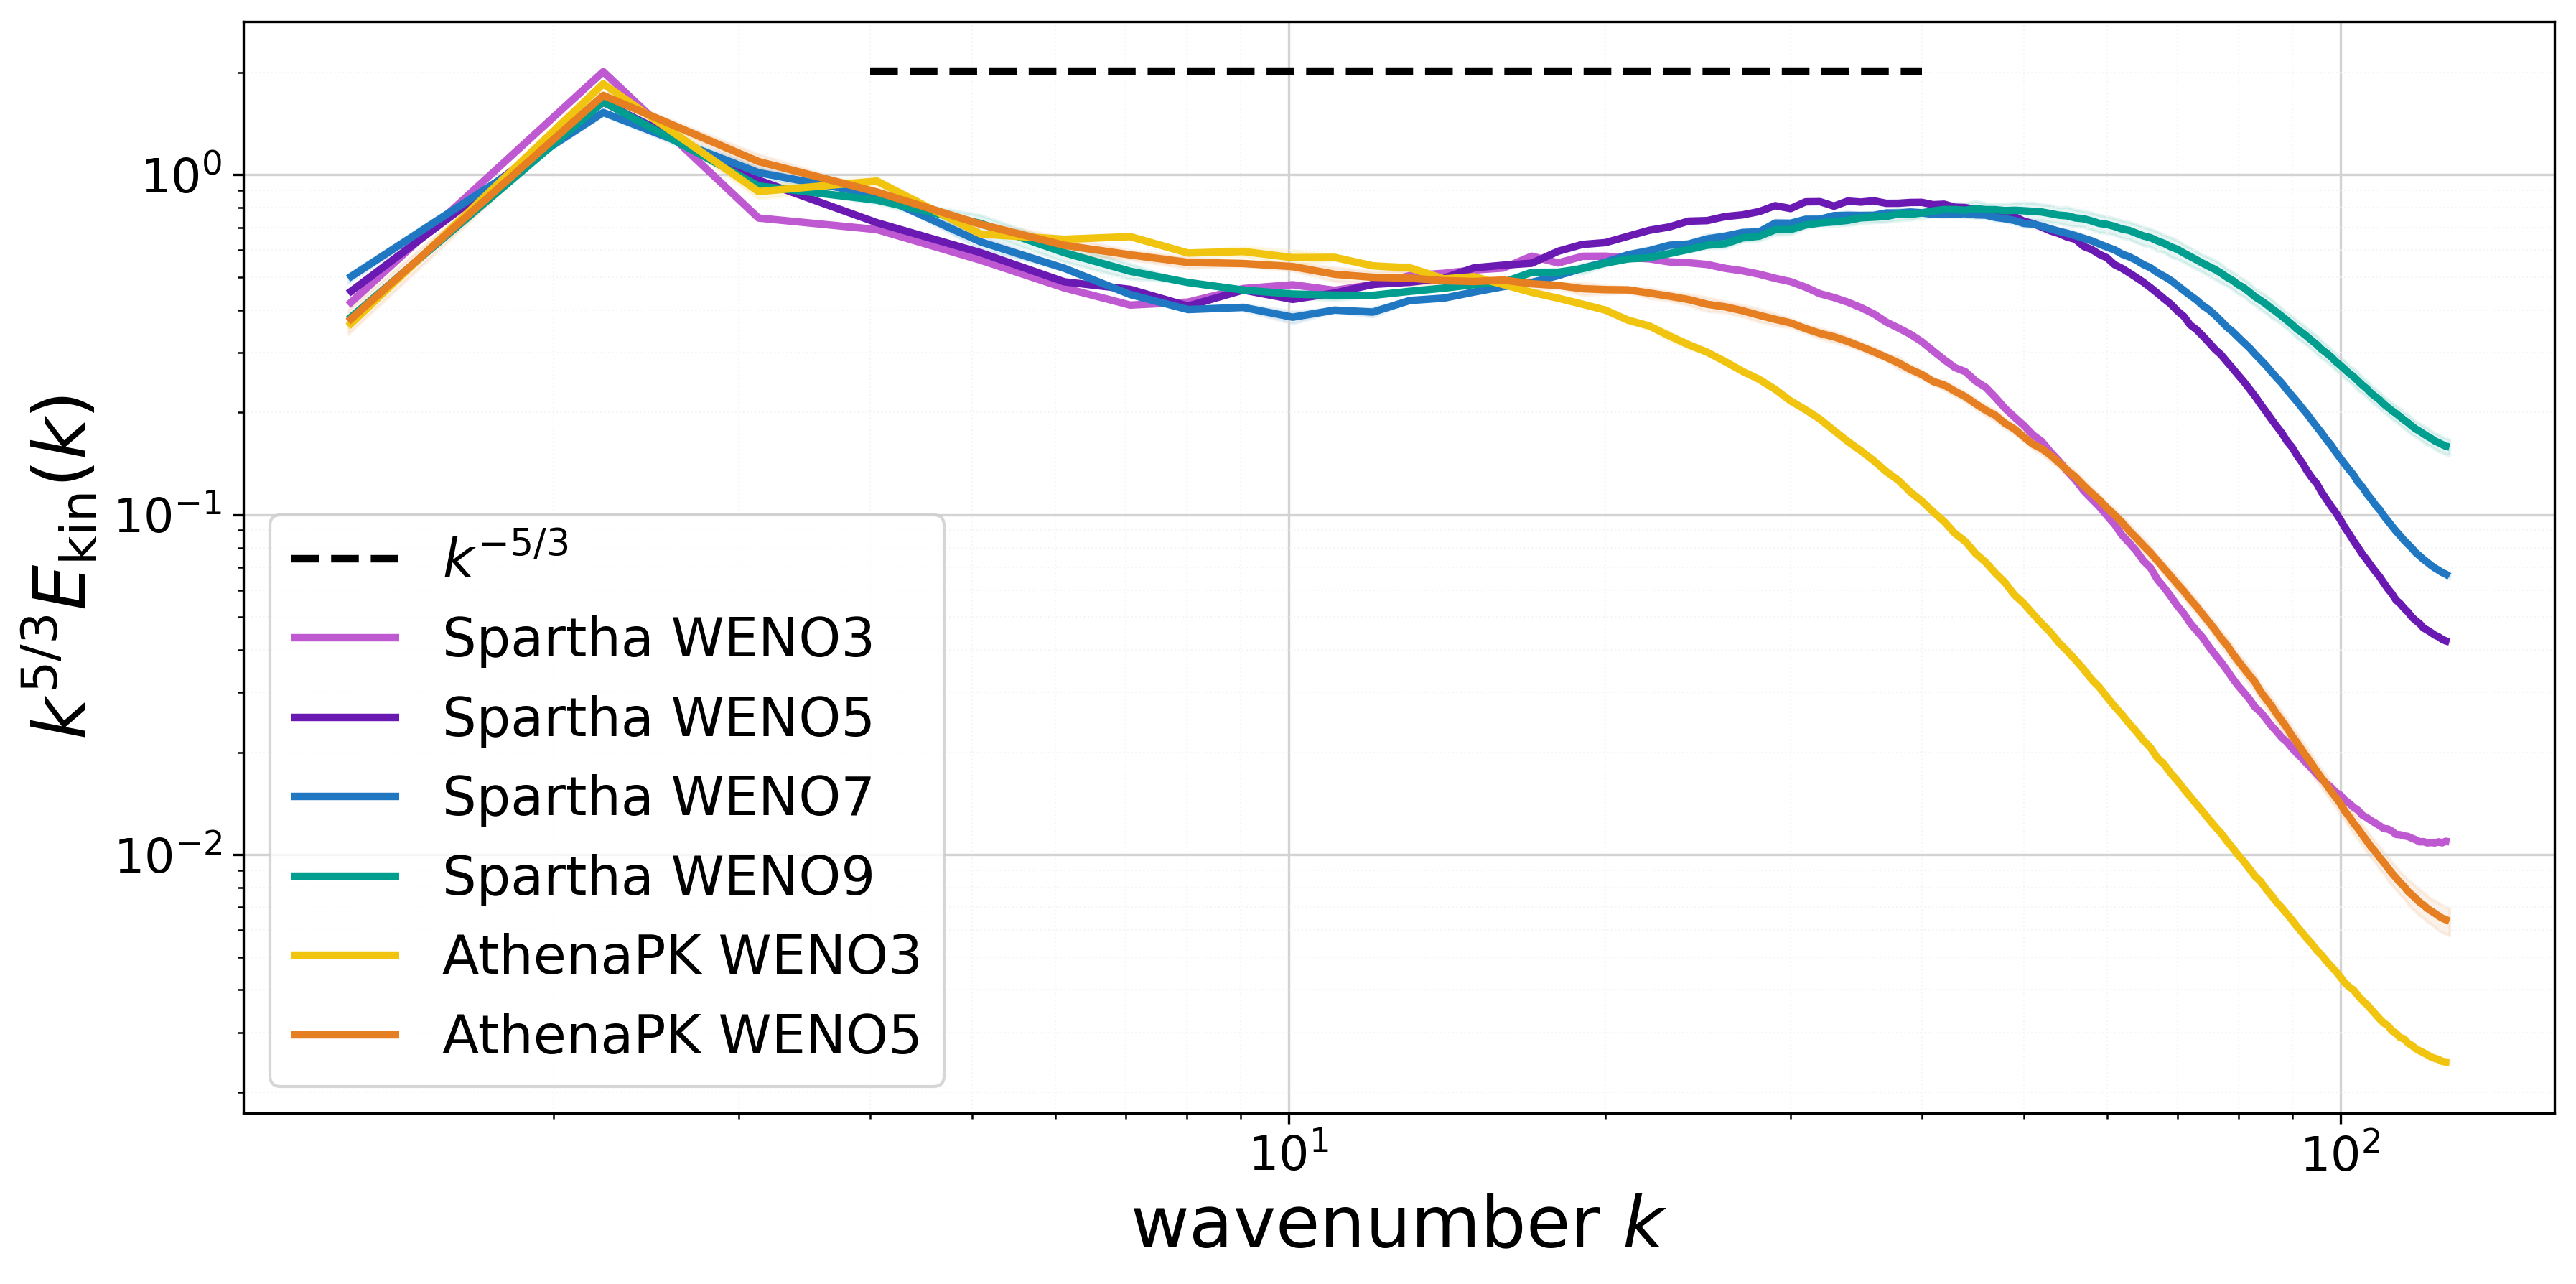

In [ ]:
ids_this_plot = [

    'data/spartha-weno3',
    'data/spartha-weno5',
    'data/spartha-weno7',
    'data/spartha-weno9',
    'data/athenapk-weno3',
    'data/athenapk-weno5',
]

fig = plt.figure(figsize=(12, 6),dpi=300) 

use_norm = None

############################################################################################
# Add Reference k^{-5/3} Line
############################################################################################

x_ref = np.array([4e0, 4e1])          # range in k/k_f (adjust as needed)
y_ref_start = 2e-1                    # choose where the line starts vertically
y_ref = y_ref_start * (x_ref / x_ref[0])**(-5/3)

# plt.plot(x_ref, y_ref, ls='--',color='black', lw=2.5, label=r'$k^{-5/3}$')            # Regular
plt.plot(x_ref, y_ref*x_ref**(5/3), ls='--',color='black', lw=2.5, label=r'$k^{-5/3}$') # Compensated

############################################################################################
# Add Kinetic / Magnetic Spectra
############################################################################################

for this_id in ids_this_plot:

    term = 'rhoU'
    # term = 'B'
    ana_res = sim_dict[this_id]['analysis_res']

    tlim_low = sim_dict[this_id]['stationary_ids'][0] * sim_dict[this_id]['time_between_dumps']
    tlim_up  = sim_dict[this_id]['stationary_ids'][1] * sim_dict[this_id]['time_between_dumps']

    X, Y, Yerr = add_mean_spec_to_plot(this_id, ana_res, term +'/PowSpec/Full', tlim_low=tlim_low, tlim_up=tlim_up, use_norm=use_norm)

    plt.plot(X,Y*X**(5/3),lw=2.5,ls=sim_dict[this_id]['style']['ls'],color=sim_dict[this_id]['style']['color'],label=sim_dict[this_id]['style']['label'])
    plt.fill_between(X,(Y - Yerr)*X**(5/3),(Y + Yerr)*X**(5/3),alpha=0.1,color=sim_dict[this_id]['style']['color']) 
    
    # plt.plot(X,Y,lw=2.5,ls=sim_dict[this_id]['style']['ls'],color=sim_dict[this_id]['style']['color'],label=sim_dict[this_id]['style']['label'])
    # plt.fill_between(X,(Y - Yerr),(Y + Yerr),alpha=0.1,color=sim_dict[this_id]['style']['color']) 

############################################################################################
# Formatting 
############################################################################################

plt.xscale('log')
plt.yscale('log')

# plt.ylim([8E-3,9E0])

plt.xlabel(r'wavenumber $k$',fontsize=24)
# plt.ylabel(r"$E_{\text{kin}}(k)$",fontsize=24)
plt.ylabel(r"$k^{5/3} E_{\text{kin}}(k)$",fontsize=24)
# plt.ylabel(r"$k^{5/3} E_{\text{mag}}(k)$",fontsize=24)

plt.grid(which='major', color='lightgray', linestyle='-', linewidth=0.8)  
plt.minorticks_on()  
plt.grid(which='minor', color='whitesmoke', linestyle=':', linewidth=0.5) 

plt.tick_params(axis='both', labelsize=16)
plt.legend(fontsize=18, loc='lower left')

fig.tight_layout()
# fig.savefig('kin_spectra.pdf', dpi=150, bbox_inches='tight')
